# R_COMP FREE: does cross-family solver consensus beat a cheap LLM judge on long free-vocabulary sentences?

This notebook is a runnable walkthrough of the iteration-5 experiment **R_COMP FREE confirmation** (`gen_art_experiment_13`). It is part of a study of **gold-free faithfulness metrics for NL→FOL translation**.

**The metric.** `c_score_align` is **cross-family solver consensus**. Several LLMs from *other* model families translate the same sentence. A peer *agrees* with the candidate formula when z3 proves the two formulas equivalent after a name-similarity **aligner** maps the peer's predicates onto the candidate's. The score is the share of peers that do **not** agree, so a higher score means the candidate is more likely an ERROR. `c_exact` is the same idea with no aligner (exact lower-cased names).

**The baseline.** A cheap LLM judge (gemini flash-lite, rubric A). It sees the sentence either with the predicate names disguised (`judge_cheap_disg`) or in its original wording (`judge_cheap_orig`).

**The data.** R_COMP FREE has 2,652 free-vocabulary FOL translations of 221 **templated** long rule sentences (9 templates, 10 LLM slots from 9 families). Labels come from the frozen dataset-5 labeller:
* `ERROR_CERT`: an exhaustive vocabulary-map search found **no** mapping onto the reference that makes the candidate equivalent. This is a certificate of error.
* `MAPPED`: some mapping makes it equivalent. These rows were supposed to be confirmed CORRECT by a two-checker "gloss gate" that asks whether the mapping is semantically faithful.

**What happened.** The gloss gate **failed twice**: both checkers were below the 0.90 balanced-accuracy bar. Under the pre-registered FALLBACK B, every MAPPED row became `UNRESOLVED_GLOSS_GATE_FAILED`, leaving **0 CORRECT rows**. So the confirmatory test of criterion (c) is **NOT_TESTABLE**. A **provisional, non-confirmatory** view, pre-registered in an addendum before the join, compares ERROR_CERT (y = 1) with MAPPED (y = 0) on untouched rows. That view is what this notebook reproduces. Every AUROC is **within-template**. Every CI is a template-stratified sentence bootstrap.

**Full-run result (provisional).**

| comparison | c_align AUROC | judge AUROC | Δ [95% CI] |
|---|---|---|---|
| disguised view (n 1,706) | 0.801 | 0.584 | +0.217 [0.175, 0.260] |
| original view (n 1,709) | 0.804 | 0.633 | +0.171 [0.135, 0.206] |
| frontier judge gemini-3.1-pro, original view (150 rows) | 0.801 | 0.852 | −0.051 [−0.153, 0.044] |

Caveats the notebook also shows: the aligner-free `c_exact` is about level with the judge, so the advantage comes from the aligner; the original-view advantage **shrinks with sentence length**; and the pre-registered placebo bar failed (17/20 vs 18/20).

**What this demo runs.** `method.py` is a stage orchestrator that shells out to one script per step. Most steps are paid API calls whose outputs are sealed files. The notebook keeps the orchestrator as written and runs it **dry** (it prints the commands). It then inlines the $0 **analysis** step (`confirm/join_and_test.py` with `confirm/analysis_lib.py` and `confirm/auc_tools.py`) and runs it on the sealed labels and scores of a curated subset: **100 of the 221 sentences, with all 1,200 of their candidate rows**. The last cells compare the subset numbers with the full-run numbers stored in the data file.

In [1]:
%%capture
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only (at Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

## Imports
The first block is `method.py`'s original import block. The second is `confirm/join_and_test.py`'s, together with what `analysis_lib.py`, `auc_tools.py` and `cc.py` import (`math`, `LogisticRegression`). The last line adds matplotlib for the figures.

In [2]:
# --- original method.py imports ---
from __future__ import annotations

import argparse
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- original confirm/join_and_test.py imports (+ analysis_lib.py / auc_tools.py / cc.py) ---
import glob
import json
import math
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from scipy.stats import kendalltau
from sklearn.linear_model import LogisticRegression

# --- demo only ---
import matplotlib.pyplot as plt

## Data loading
`mini_demo_data.json` is loaded from GitHub (for Colab), with the local copy as a fallback. It contains:
* `labels`: one sealed label record per candidate row, from `results/rcomp_free_labels_final.jsonl`, trimmed to the fields the join reads plus the sentence `text`.
* `scores`: one sealed score record per candidate row (`results/scores_rcomp_free.jsonl`). It holds every metric (`c_score_align`, `c_exact`, `c_score_hyb`, `c_score_nf`, `g_*`, the cheap and local judges, V1–V5), the strata (`template_id`, `word_tercile`, `nconds_weak`), the `untouched` flag and the cross-fit `fold`.
* `frontier`: the gemini-3.1-pro judge scores (as `1 − p`) for the frontier-sample rows that fall in this subset.
* `v4_selection`: the M1-frozen coefficients of consensus variant V4 (`freeze_copy/selection.json`).
* `metadata.full_run_reference`: the full-run numbers from `results/analysis_rcomp.json`, used for comparison.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_e4aqYfQhdCkX/round-5/experiment-13/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print(f"{len(data['labels'])} label rows, {len(data['scores'])} score rows, "
      f"{len(data['frontier']['sample_row_keys'])} frontier-sample rows")
print("sentences per template:", data["metadata"]["sentences_per_template"])

R_COMP FREE (iteration 5, gen_art_experiment_13): sealed labels + sealed metric scores for every candidate row of 100 of the 221 templated long rule sentences (1200 of 2,652 rows), template-proportional deterministic sample.
1200 label rows, 1200 score rows, 62 frontier-sample rows
sentences per template: {'T1': 12, 'T3': 10, 'T2': 13, 'T6': 11, 'T7': 12, 'T8': 10, 'T5': 12, 'T4': 11, 'T9': 9}


## Config
All tunable parameters are here.
* `N_SENTENCES`: how many of the subset's 100 sentences to analyse (all of each sentence's candidate rows are kept).
* `B`: bootstrap replicates. The original uses **2000** (`cc.B`), and so does this demo.
* `SEED`: the original seed (`cc.SEED`).
* `N_PERM`: label permutations for the nested-model null. The original uses **50** (10 with `--quick`).
* `N_SHUFFLE`: within-template label-shuffle placebo runs. The original uses **20** (5 with `--quick`).
* `N_SUPPLEMENT`: the post-hoc 100-shuffle placebo supplement (D26). The original uses **100**, and so does this demo.

Every statistical parameter is at its original value, and the whole notebook runs in about 3 minutes. The only reduction is the data: 100 of the 221 sentences.
* `DRY_RUN`: the orchestrator prints its step commands instead of running them, because the step scripts and sealed inputs are not part of this demo.

In [5]:
N_SENTENCES = 100    # subset holds 100 of the 221 sentences (all 2,652 rows in the full run)
B = 2000             # original: B = 2000  (cc.py); --quick uses 200
SEED = 20260924      # original: SEED = 20260924 (cc.py)
N_PERM = 50          # original: n_perm = 50 for nesting (10 with --quick)
N_SHUFFLE = 20       # original: 20 within-template label shuffles (5 with --quick)
N_SUPPLEMENT = 100   # original: 100 post-hoc supplement shuffles (D26)
DRY_RUN = True       # the step scripts are not shipped with the demo: print the commands instead of running them

## The orchestrator: `method.py`
This is `method.py` as written. It maps each pre-registered step to its script and runs the steps in order. The default `--steps` is the $0 tail `analysis,report,checks`. Paid steps (`judge_orig`, `pilot`, `gate`, `audit`, `frontier`) are cached and ledgered, so re-running never re-bills.

Changes for the notebook: `WS` is the current directory rather than `__file__`, `parse_args([])` replaces reading the command line, and with `DRY_RUN` the `subprocess.run` call is replaced by logging the command. The next cells run the `analysis` step's code inline.

In [6]:
WS = Path(".")  # original: Path(__file__).resolve().parent
PY = Path(sys.executable).name  # original: sys.executable (short name here so the dry-run log carries no machine path)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(WS / "logs").mkdir(exist_ok=True)
logger.add(WS / "logs/method.log", rotation="30 MB", level="DEBUG")

STEPS = {
    "g0": [["confirm/g0_repro.py"]],
    "judge_orig": [["confirm/judge_orig_complete.py"]],
    "scores": [["confirm/scores.py"]],
    "prereg": [["confirm/prereg.py"]],
    "pilot": [["confirm/gloss_pilot.py"]],
    "gate": [["labeller/src/resume_gloss.py", "gate"], ["labeller/src/gate.py", "run", "--half", "B", "--version", "gloss_v2"]],
    "gate_diag": [["confirm/gate_diagnostics.py"]],
    "finalize": [["labeller/src/resume_gloss.py", "finalize", "--version", "gloss_v2"]],
    "audit": [["confirm/audit_blind.py"]],
    "frontier": [["confirm/frontier_judge.py"]],
    "analysis": [["confirm/join_and_test.py"]],
    "report": [["confirm/report.py"]],
    "checks": [["tests/rederive_confirm.py"], ["confirm/write_deviations.py"], ["confirm/final_checks.py"]],
}


@logger.catch(reraise=True)
def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--steps", default="analysis,report,checks")
    a = ap.parse_args([])  # notebook: no command line
    for st in a.steps.split(","):
        for cmd in STEPS[st]:
            script = WS / cmd[0]
            cwd = script.parent if cmd[0].startswith("confirm/") else (WS / "labeller" if cmd[0].startswith("labeller/") else WS)
            args = [PY, str(script)] + cmd[1:]
            if cmd[0].startswith("labeller/"):
                args = [PY, str(Path(cmd[0]).relative_to("labeller"))] + cmd[1:]
            logger.info(f"[{st}] $ {' '.join(args)}")
            if not DRY_RUN:  # demo: the step scripts are not shipped with the notebook
                subprocess.run(args, check=True, cwd=cwd)
    logger.info("done")


main()

12:01:58|INFO   |[analysis] $ python confirm/join_and_test.py


12:01:58|INFO   |[report] $ python confirm/report.py


12:01:58|INFO   |[checks] $ python tests/rederive_confirm.py


12:01:58|INFO   |[checks] $ python confirm/write_deviations.py


12:01:58|INFO   |[checks] $ python confirm/final_checks.py


12:01:58|INFO   |done


## Shared helpers from `confirm/cc.py`
`jl` (read JSONL) and `wilson` (Wilson score interval, used for operating points), copied verbatim. `B` and `SEED` come from the config cell.

In [7]:
def jl(p) -> list:
    return [json.loads(l) for l in Path(p).open() if l.strip()]


def wilson(k: int, n: int, z: float = 1.96) -> list:
    if n == 0:
        return [None, None]
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return [round(c - h, 4), round(c + h, 4)]

## Within-template AUROC and the cluster bootstrap: `confirm/auc_tools.py` (verbatim)
`StratAUC` computes a **stratified** AUROC: inside each stratum (here, each template) it counts ERROR×MAPPED pairs where the ERROR row scores higher (ties count 0.5), then pools the counts over strata. This removes between-template differences in base rate and score level.

`boot_weights` draws a **sentence (cluster) bootstrap** that resamples sentences with replacement *within* their template. Each row inherits its sentence's multiplicity, so candidate rows of the same sentence are never treated as independent.

In [8]:
class StratAUC:
    """Precomputes per-stratum score ranks once; value(cluster_weights) is then O(n) per replicate."""

    def __init__(self, score: np.ndarray, is_err: np.ndarray, stratum: np.ndarray, cluster: np.ndarray,
                 stratum_is_cluster: bool = False):
        score = np.asarray(score, dtype=float)
        is_err = np.asarray(is_err, dtype=bool)
        self.linear = stratum_is_cluster
        self.parts = []
        for s in np.unique(stratum):
            m = stratum == s
            y = is_err[m]
            if y.all() or (~y).all():
                continue
            u, g = np.unique(score[m], return_inverse=True)
            self.parts.append((g.astype(np.int64), y, cluster[m], len(u)))

    def value(self, cw: np.ndarray | None = None) -> float:
        U = P = 0.0
        for g, y, cl, ng in self.parts:
            if cw is None:
                w = np.ones(len(g))
            else:
                w = cw[cl].astype(float)
                if self.linear:
                    w = np.sqrt(w)
            negw = np.bincount(g[~y], w[~y], minlength=ng)
            posw = np.bincount(g[y], w[y], minlength=ng)
            below = np.cumsum(negw) - negw
            U += float((posw * (below + 0.5 * negw)).sum())
            P += float(posw.sum() * negw.sum())
        return U / P if P > 0 else float("nan")

    def n_pairs(self) -> int:
        return int(sum(int(y.sum()) * int((~y).sum()) for _, y, _, _ in self.parts))


def boot_weights(cluster_stratum: np.ndarray, B: int, seed: int) -> np.ndarray:
    """(B, n_clusters) integer multiplicities; clusters resampled with replacement within their stratum (template)."""
    rng = np.random.default_rng(seed)
    n = len(cluster_stratum)
    W = np.zeros((B, n), dtype=np.int32)
    groups = [np.flatnonzero(cluster_stratum == s) for s in np.unique(cluster_stratum)]
    for b in range(B):
        for idx in groups:
            draw = rng.choice(idx, size=len(idx), replace=True)
            np.add.at(W[b], draw, 1)
    return W

## Paired deltas, nesting and operating points: `confirm/analysis_lib.py`
* `Boot` holds **one** set of bootstrap weights shared by every metric and population, so a paired delta between two metrics uses the same resamples for both.
* `auc_block` gives one metric's AUROC with its CI. `paired_delta` gives AUROC(a) − AUROC(b) on rows where both are scored, with a CI and a two-sided bootstrap sign p.
* `nested_block` asks whether adding a metric to a logistic model improves on the base model: [base + add] − [base], using 5-fold sentence cross-fitting and a within-template label-permutation null.
* `op_point` / `thr_at_fa` give recall, false-alarm rate (FA) and precision at a threshold.

The code is verbatim. The one change: `op_point` does `from cc import wilson`, and here `wilson` is already defined in the cell above.

In [9]:
class Boot:
    """One set of bootstrap weights over ALL sentences (clusters), resampled within template; shared by every metric,
    population and delta, so that paired comparisons use the SAME resamples."""

    def __init__(self, sentence_ids: list[str], sentence_template: dict, B: int, seed: int):
        self.sids = sorted(sentence_ids)
        self.ix = {s: i for i, s in enumerate(self.sids)}
        cs = np.array([sentence_template[s] for s in self.sids])
        self.W = boot_weights(cs, B, seed)
        self.B = B

    def cl(self, sids) -> np.ndarray:
        return np.array([self.ix[s] for s in sids], dtype=np.int64)


def _arr(df, col):
    return df[col].to_numpy(dtype=float)


def auc_block(df, score: str, boot: Boot, ycol: str = "y", stratum: str = "template_id", with_boot: bool = True) -> dict:
    d = df[df[score].notna() & df[ycol].notna()]
    y = d[ycol].to_numpy().astype(bool)
    out = {"n": int(len(d)), "n_err": int(y.sum()), "n_cor": int((~y).sum()), "n_sent": int(d.sentence_id.nunique()),
           "n_sent_err": int(d[y].sentence_id.nunique()), "n_sent_cor": int(d[~y].sentence_id.nunique())}
    if y.all() or (~y).all() or len(d) == 0:
        out.update(est=None, ci=[None, None], se=None)
        return out
    st = d[stratum].to_numpy() if stratum != "pooled" else np.zeros(len(d))
    A = StratAUC(_arr(d, score), y, st, boot.cl(d.sentence_id))
    out["est"] = A.value()
    if with_boot:
        bs = np.array([A.value(boot.W[b]) for b in range(boot.B)])
        bs = bs[~np.isnan(bs)]
        out["ci"] = [float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))]
        out["se"] = float(np.std(bs, ddof=1))
    return out


def paired_delta(df, a: str, b: str, boot: Boot, ycol: str = "y", stratum: str = "template_id") -> dict:
    """AUROC_within(a) - AUROC_within(b) on rows where both are scored, same bootstrap weights."""
    d = df[df[a].notna() & df[b].notna() & df[ycol].notna()]
    y = d[ycol].to_numpy().astype(bool)
    out = {"a": a, "b": b, "n": int(len(d)), "n_err": int(y.sum()), "n_cor": int((~y).sum()), "n_sent": int(d.sentence_id.nunique())}
    if len(d) == 0 or y.all() or (~y).all():
        out.update(delta=None, ci=[None, None], p_two_sided=None, auroc_a=None, auroc_b=None)
        return out
    st = d[stratum].to_numpy() if stratum != "pooled" else np.zeros(len(d))
    cl = boot.cl(d.sentence_id)
    A = StratAUC(_arr(d, a), y, st, cl)
    Bm = StratAUC(_arr(d, b), y, st, cl)
    ea, eb = A.value(), Bm.value()
    ba = np.array([A.value(boot.W[i]) for i in range(boot.B)])
    bb = np.array([Bm.value(boot.W[i]) for i in range(boot.B)])
    dd = ba - bb
    ok = ~np.isnan(dd)
    dd, ba, bb = dd[ok], ba[ok], bb[ok]
    out.update(auroc_a=ea, auroc_b=eb, auroc_a_ci=[float(np.percentile(ba, 2.5)), float(np.percentile(ba, 97.5))],
               auroc_b_ci=[float(np.percentile(bb, 2.5)), float(np.percentile(bb, 97.5))], delta=ea - eb,
               ci=[float(np.percentile(dd, 2.5)), float(np.percentile(dd, 97.5))], se=float(np.std(dd, ddof=1)),
               p_two_sided=float(min(1.0, 2 * min((dd <= 0).mean(), (dd >= 0).mean()))), ci_lower_gt_0=bool(np.percentile(dd, 2.5) > 0),
               ratio=(ea / eb) if eb else None, ratio_ci=[float(np.percentile(ba / bb, 2.5)), float(np.percentile(ba / bb, 97.5))])
    return out


def delta_boot_vector(df, a: str, b: str, boot: Boot, ycol: str = "y") -> tuple[float, np.ndarray]:
    d = df[df[a].notna() & df[b].notna() & df[ycol].notna()]
    y = d[ycol].to_numpy().astype(bool)
    st = d.template_id.to_numpy()
    cl = boot.cl(d.sentence_id)
    A, Bm = StratAUC(_arr(d, a), y, st, cl), StratAUC(_arr(d, b), y, st, cl)
    return A.value() - Bm.value(), np.array([A.value(boot.W[i]) - Bm.value(boot.W[i]) for i in range(boot.B)])


def holm(pvals: dict) -> dict:
    items = sorted(pvals.items(), key=lambda kv: kv[1])
    m = len(items)
    adj, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        adj[k] = run
    return adj


# ------------------------------------------------------------------------------------------ nesting
def _ecdf_map(train: np.ndarray, x: np.ndarray) -> np.ndarray:
    s = np.sort(train)
    lo = np.searchsorted(s, x, side="left")
    hi = np.searchsorted(s, x, side="right")
    return (lo + hi) / (2.0 * len(s))


def crossfit_oof(d, features: list[str], ycol: str = "y", C: float = 1.0) -> np.ndarray:
    """5 sentence folds (d.fold); features rank-normalised by the TRAIN fold's ECDF; logistic OOF probabilities."""
    y = d[ycol].to_numpy().astype(int)
    out = np.full(len(d), np.nan)
    folds = d.fold.to_numpy()
    X = d[features].to_numpy(dtype=float)
    for f in range(5):
        te, tr = folds == f, folds != f
        if te.sum() == 0 or len(set(y[tr])) < 2:
            continue
        Xtr = np.column_stack([_ecdf_map(X[tr, j], X[tr, j]) for j in range(X.shape[1])])
        Xte = np.column_stack([_ecdf_map(X[tr, j], X[te, j]) for j in range(X.shape[1])])
        m = LogisticRegression(C=C, max_iter=1000).fit(Xtr, y[tr])
        out[te] = m.predict_proba(Xte)[:, 1]
    return out


def nested_block(df, base: list[str], add: list[str], boot: Boot, ycol: str = "y", n_perm: int = 50, seed: int = 20260924) -> dict:
    """[base+add] - [base] within-template AUROC of cross-fitted OOF predictions, bootstrap over sentences on the fixed
    OOF predictions (no refit per replicate), plus a within-template label-permutation null with refits."""
    cols = base + add
    d = df[df[cols].notna().all(axis=1) & df[ycol].notna()].copy()
    d["_p_base"] = crossfit_oof(d, base, ycol)
    d["_p_full"] = crossfit_oof(d, cols, ycol)
    r = paired_delta(d, "_p_full", "_p_base", boot, ycol)
    rng = np.random.default_rng(seed)
    null = []
    for _ in range(n_perm):
        dp = d.copy()
        yp = dp[ycol].to_numpy().copy()
        for t in np.unique(dp.template_id):
            m = dp.template_id.to_numpy() == t
            yp[m] = rng.permutation(yp[m])
        dp["_yp"] = yp
        dp["_pb"] = crossfit_oof(dp, base, "_yp")
        dp["_pf"] = crossfit_oof(dp, cols, "_yp")
        yb = dp._yp.to_numpy().astype(bool)
        st, cl = dp.template_id.to_numpy(), boot.cl(dp.sentence_id)
        null.append(StratAUC(dp._pf.to_numpy(), yb, st, cl).value() - StratAUC(dp._pb.to_numpy(), yb, st, cl).value())
    null = np.array(null)
    return {"model_base": base, "model_full": cols, "n": int(len(d)), "auroc_full": r.get("auroc_a"), "auroc_base": r.get("auroc_b"),
            "delta": r.get("delta"), "ci": r.get("ci"), "p_two_sided": r.get("p_two_sided"),
            "perm_null_p95": float(np.percentile(null, 95)), "perm_null_mean": float(null.mean()), "n_perm": n_perm,
            "delta_gt_null_p95": bool(r.get("delta") is not None and r["delta"] > np.percentile(null, 95)),
            "note": "bootstrap over sentences on fixed OOF predictions (no refit per replicate); permutation null refits"}


# ------------------------------------------------------------------------------------------ operating points
def op_point(df, score: str, thr: float, ycol: str = "y") -> dict:
    # original: from cc import wilson  (wilson is defined in the cc.py cell above)
    d = df[df[score].notna() & df[ycol].notna()]
    y = d[ycol].to_numpy().astype(bool)
    f = d[score].to_numpy() > thr
    tp, fp = int((f & y).sum()), int((f & ~y).sum())
    return {"threshold_gt": thr, "n_err": int(y.sum()), "n_cor": int((~y).sum()), "recall": tp / max(y.sum(), 1),
            "recall_ci": wilson(tp, int(y.sum())), "FA": fp / max((~y).sum(), 1), "FA_ci": wilson(fp, int((~y).sum())),
            "precision": tp / max(tp + fp, 1), "precision_ci": wilson(tp, tp + fp), "n_flagged": int(f.sum())}

## Joining the sealed labels and scores: `load_joined` (from `confirm/join_and_test.py`)
The original first verifies the SHA-256 seals of the label file, the score file and both preregistrations, and refuses to join if any check fails. The sealed files are not shipped with this demo, so that step is skipped here. The join itself is verbatim, except that it reads from `data` instead of `results/*.jsonl`:
* `y_conf` is the **confirmatory** label (gated CORRECT vs ERROR). It has no CORRECT rows because of FALLBACK B.
* `y` is the **provisional** label: ERROR_CERT = 1, MAPPED (`UNRESOLVED_GLOSS_GATE_FAILED`) = 0. Every other label (UNPARSEABLE, NO_OUTPUT, …) is NaN and drops out.
* `V4_c_two_channel` applies the M1-frozen logistic coefficients to the sealed `c_exact` and `c_score_align` columns.

In [10]:
METRICS = ["c_score_align", "c_exact", "c_score_hyb", "c_score_nf", "g_align", "g_nf", "judge_cheap_disg", "judge_cheap_orig",
           "judge_local_disg", "judge_local_orig"]
VARIANTS = ["V1_c_pn", "V2_c_rw", "V3_c_pn_rw", "V5_c_v5"]
MAPPED = "UNRESOLVED_GLOSS_GATE_FAILED"
QWEN_SLOT_MODEL = "qwen/qwen3-235b-a22b-2507"


def load_joined() -> pd.DataFrame:
    labs = {r["row_key"]: r for r in data["labels"]}  # original: jl(RES / "rcomp_free_labels_final.jsonl")
    sc = data["scores"]                               # original: jl(RES / "scores_rcomp_free.jsonl")
    rows = []
    for s in sc:
        l = labs[s["row_key"]]
        cert = l.get("nonequiv_certificate_type_counts") or {}
        rows.append({**{k: v for k, v in s.items() if k not in ("s1_detectors",)}, "s1_detectors": ",".join(s["s1_detectors"]),
                     "label": l["label"], "label_binary": l["label_binary"], "matched_reading_search": l.get("matched_reading_search"),
                     "cert_dominant": max(cert, key=cert.get) if cert else None, "cert_counts": json.dumps(cert),
                     "old_label_iter3": l.get("old_label_iter3")})
    D = pd.DataFrame(rows)
    D["y_conf"] = D.label_binary.map({"ERROR": 1.0, "CORRECT": 0.0})
    D["y"] = D.label.map({"ERROR_CERT": 1.0, MAPPED: 0.0})
    D["qwen_slot"] = D.system.str.contains(QWEN_SLOT_MODEL, regex=False)
    sel = data.get("v4_selection")  # original: WS / "freeze_copy/selection.json"
    if sel:  # M1 frozen V4 coefficients (label-free application to two SEALED columns)
        co = sel["V4_coefficients_frozen"]
        z = co["intercept"] + co["c_exact"] * D.c_exact + co["c_align"] * D.c_score_align
        D["V4_c_two_channel"] = 1 / (1 + np.exp(-z))
        if "V4_c_two_channel" not in VARIANTS:
            VARIANTS.append("V4_c_two_channel")
    D["not_end_maj_align"] = 1.0 - D.end_maj_align.astype(float)
    D["not_end_maj_exact"] = 1.0 - D.end_maj_exact.astype(float)
    return D


def view_pop(D: pd.DataFrame, judge: str, untouched: bool = True) -> pd.DataFrame:
    m = D.y.notna() & D.c_score_align.notna() & D[judge].notna()
    if untouched:
        m &= D.untouched
    return D[m]

In [11]:
D = load_joined()
keep_sids = sorted(D.sentence_id.unique())[:N_SENTENCES]  # config: analyse the first N_SENTENCES sentences of the subset
D = D[D.sentence_id.isin(keep_sids)].reset_index(drop=True)
print(f"{len(D)} candidate rows, {D.sentence_id.nunique()} sentences, {D.template_id.nunique()} templates")
print("label counts:", dict(Counter(D.label)))
ex = D[D.y.notna()].groupby("label").head(1)
txt = {r["row_key"]: r["text"] for r in data["labels"]}
for r in ex.itertuples():
    print(f"\n[{r.label}] {r.template_id} {r.words} words | c_align={r.c_score_align:.3f} judge_disg={r.judge_cheap_disg}")
    print("  text:", txt[r.row_key])
    print("  FOL :", r.candidate_fol)

1200 candidate rows, 100 sentences, 9 templates
label counts: {'UNRESOLVED_GLOSS_GATE_FAILED': 667, 'ERROR_CERT': 375, 'UNPARSEABLE': 68, 'NO_OUTPUT': 90}

[UNRESOLVED_GLOSS_GATE_FAILED] T3 35 words | c_align=0.500 judge_disg=1.0
  text: Any certified public accountant that lives in California and that does not play a lot of chess is born in New York City, provided that the certified public accountant loses time and works from home.
  FOL : ∀x ((CertifiedPublicAccountant(x) ∧ LivesIn(x, california) ∧ ¬PlayLotsOf(x, chess) ∧ LoseTime(x) ∧ WorkFromHome(x)) → BornIn(x, newYorkCity))

[ERROR_CERT] T1 35 words | c_align=1.000 judge_disg=0.050000000000000044
  text: Every cell that has high engagement metrics, that is made from grain, and that has a flat surface is an area of land saturated with water, unless the cell is used in the lab computer.
  FOL : ∀x ((Cell(x) ∧ HighEngagementMetrics(x) ∧ MadeFromGrain(x) ∧ FlatSurface(x)) → (AreaOfLandSaturatedWithWater(x) ⊕ ¬UsedInLabComputer(x)))


## The analyses (from `confirm/join_and_test.py`, verbatim)
* `confirmatory`: the pre-registered testability check. At least 50 ERROR and 50 CORRECT rows from at least 25 sentences each are required. With 0 CORRECT rows the verdict is NOT_TESTABLE.
* `metric_table`: within-template and pooled AUROC for every metric.
* `headline`: the paired delta c_align − judge in both judge views.
* `sensitivities`: the headline under row filters (drop detector-flagged rows, drop the qwen slot, few-shot only, common support, …) and per template (s4).
* `exploratory_variants`: consensus variants V1–V5 against c_align and against the judge, with Holm-adjusted p-values.
* `complexity`: the headline delta per word-length tercile and per condition count, plus the W3 − W1 "delta of deltas".
* `placebos`: within-template label shuffles (the delta CI should cover 0) and a random score (AUROC ≈ 0.5).
* `frontier_view`: c_align against the gemini-3.1-pro frontier judge on the frontier-sample rows. It is adapted to read the frontier scores from `data`, and it uses `N_PERM` instead of a hard-coded 50.

In [12]:
def confirmatory(D: pd.DataFrame) -> dict:
    out = {}
    for view, j in (("disg", "judge_cheap_disg"), ("orig", "judge_cheap_orig")):
        P = D[D.untouched & D.y_conf.notna() & D.c_score_align.notna() & D[j].notna()]
        n1, n0 = int((P.y_conf == 1).sum()), int((P.y_conf == 0).sum())
        s1, s0 = P[P.y_conf == 1].sentence_id.nunique(), P[P.y_conf == 0].sentence_id.nunique()
        out[view] = {"n_ERROR": n1, "n_CORRECT": n0, "sentences_ERROR": int(s1), "sentences_CORRECT": int(s0),
                     "TESTABLE": bool(n1 >= 50 and n0 >= 50 and s1 >= 25 and s0 >= 25)}
    out["verdict"] = "NOT_TESTABLE" if not (out["disg"]["TESTABLE"] and out["orig"]["TESTABLE"]) else "TESTABLE"
    out["reason"] = ("FALLBACK B: the gloss gate failed twice (gloss_v1 half A, gloss_v2 half B); every MAPPED row is "
                     "UNRESOLVED_GLOSS_GATE_FAILED, so the gated label set has 0 CORRECT rows")
    out["label_counts_all"] = dict(Counter(D.label))
    out["label_counts_untouched"] = dict(Counter(D[D.untouched].label))
    return out


def metric_table(P: pd.DataFrame, boot: Boot, cols: list[str], ycol: str = "y") -> dict:
    out = {}
    for m in cols:
        out[m] = {"within_template": auc_block(P, m, boot, ycol), "pooled": auc_block(P, m, boot, ycol, stratum="pooled")}
    return out


def headline(D: pd.DataFrame, boot: Boot, untouched: bool = True, ycol: str = "y") -> dict:
    o = {}
    for view, j in (("disg", "judge_cheap_disg"), ("orig", "judge_cheap_orig")):
        P = view_pop(D, j, untouched) if ycol == "y" else D[D[ycol].notna() & D.c_score_align.notna() & D[j].notna() & (D.untouched if untouched else True)]
        o[view] = paired_delta(P, "c_score_align", j, boot, ycol)
    o["both_ci_gt_0"] = bool(o["disg"].get("ci_lower_gt_0") and o["orig"].get("ci_lower_gt_0"))
    return o


def sensitivities(D: pd.DataFrame, boot: Boot) -> dict:
    base = headline(D, boot)
    rows = {"primary_provisional": base}
    filt = {
        "s1a_drop_detector_rows": D[~D.s1_flag],
        "s1b_drop_detector_ERROR_CERT_only": D[~(D.s1_flag & (D.y == 1))],
        "s3_all_rows_incl_seen_iter3": None,
        "s5_drop_qwen235b_slot": D[~D.qwen_slot],
        "s7_fewshot_only": D[D.prompt_variant == "fewshot_v1"],
    }
    for k, d in filt.items():
        rows[k] = headline(D, boot, untouched=False) if d is None else headline(d, boot)
    P9 = D[D.judge_cheap_orig_source == "exp7"]
    rows["s9_orig_view_exp7_scored_rows_only"] = {"orig": paired_delta(view_pop(P9, "judge_cheap_orig"), "c_score_align", "judge_cheap_orig", boot)}
    P10 = D[D.judge_cheap_disg.notna() & D.judge_cheap_orig.notna()]
    rows["s10_common_support"] = headline(P10, boot)
    rows["s2_s6_s8"] = "not applicable under FALLBACK B (no gloss verdicts exist)"
    for k, v in rows.items():
        if isinstance(v, dict) and "disg" in v:
            v["flip_vs_primary"] = bool(v["both_ci_gt_0"] != base["both_ci_gt_0"])
    # s4 per template
    s4 = {}
    for t in sorted(D.template_id.unique()):
        s4[t] = headline(D[D.template_id == t], boot)
    rows["s4_per_template"] = s4
    return rows


def exploratory_variants(D: pd.DataFrame, boot: Boot) -> dict:
    P = view_pop(D, "judge_cheap_disg")
    P = P[P[VARIANTS].notna().all(axis=1)]
    out, pv = {}, {}
    for v in VARIANTS:
        for ref in ("c_score_align", "judge_cheap_disg"):
            r = paired_delta(P, v, ref, boot)
            out[f"{v} - {ref}"] = r
            pv[f"{v} - {ref}"] = r["p_two_sided"]
    adj = holm(pv)
    for k in out:
        out[k]["p_holm"] = adj[k]
    out["_auroc"] = {v: auc_block(P, v, boot) for v in VARIANTS}
    return out


def complexity(D: pd.DataFrame, boot: Boot) -> dict:
    out = {}
    for view, j in (("disg", "judge_cheap_disg"), ("orig", "judge_cheap_orig")):
        P = view_pop(D, j)
        o = {}
        for dim, vals in (("word_tercile", ["W1", "W2", "W3"]), ("nconds_weak", [4, 5])):
            o[dim] = {}
            vecs = {}
            for v in vals:
                sub = P[P[dim] == v]
                r = paired_delta(sub, "c_score_align", j, boot)
                o[dim][str(v)] = r
                if r["delta"] is not None:
                    e, bv = delta_boot_vector(sub, "c_score_align", j, boot)
                    ea, ba = delta_boot_vector(sub.assign(_z=0.5), "c_score_align", "_z", boot)
                    ej, bj = delta_boot_vector(sub.assign(_z=0.5), j, "_z", boot)
                    vecs[v] = (e, bv, ea, ba, ej, bj)
            lo, hi = vals[0], vals[-1]
            if lo in vecs and hi in vecs:
                e = vecs[hi][0] - vecs[lo][0]
                b = vecs[hi][1] - vecs[lo][1]
                sa = vecs[hi][2] - vecs[lo][2]
                sab = vecs[hi][3] - vecs[lo][3]
                sj = vecs[hi][4] - vecs[lo][4]
                sjb = vecs[hi][5] - vecs[lo][5]
                o[dim][f"delta_of_deltas_{hi}_minus_{lo}"] = {"est": e, "ci": [float(np.nanpercentile(b, 2.5)), float(np.nanpercentile(b, 97.5))]}
                o[dim][f"slope_c_align_{hi}_minus_{lo}"] = {"est": sa, "ci": [float(np.nanpercentile(sab, 2.5)), float(np.nanpercentile(sab, 97.5))]}
                o[dim][f"slope_judge_{hi}_minus_{lo}"] = {"est": sj, "ci": [float(np.nanpercentile(sjb, 2.5)), float(np.nanpercentile(sjb, 97.5))]}
        out[view] = o
    return out


def placebos(D: pd.DataFrame, boot: Boot, n_shuffle: int) -> dict:
    P = view_pop(D, "judge_cheap_disg")
    rng = np.random.default_rng(SEED)
    cover = 0
    res = []
    for i in range(n_shuffle):
        yp = P.y.to_numpy().copy()
        for t in P.template_id.unique():
            m = P.template_id.to_numpy() == t
            yp[m] = rng.permutation(yp[m])
        r = paired_delta(P.assign(_y=yp), "c_score_align", "judge_cheap_disg", boot, "_y")
        cover += int(r["ci"][0] <= 0 <= r["ci"][1])
        res.append({"delta": r["delta"], "ci": r["ci"]})
    rnd = auc_block(P.assign(_r=rng.random(len(P))), "_r", boot)
    sup_cover, sup_n = 0, 0 if n_shuffle < 20 else N_SUPPLEMENT  # original: 100
    for i in range(sup_n):  # post-hoc supplement (D26): coverage of the nominal 95% interval under the null
        yp = P.y.to_numpy().copy()
        for t in P.template_id.unique():
            m = P.template_id.to_numpy() == t
            yp[m] = rng.permutation(yp[m])
        r = paired_delta(P.assign(_y=yp), "c_score_align", "judge_cheap_disg", boot, "_y")
        sup_cover += int(r["ci"][0] <= 0 <= r["ci"][1])
    return {"supplement_100_shuffles": {"n": sup_n, "delta_ci_covers_0": sup_cover,
                                        "coverage": sup_cover / sup_n if sup_n else None, "note": "post-hoc supplement (D26)"},
            "label_shuffle_within_template": {"n": n_shuffle, "delta_ci_covers_0": cover, "pass_ge_90pct": cover >= 0.9 * n_shuffle, "runs": res},
            "random_score": {"auroc": rnd["est"], "ci": rnd["ci"], "covers_0.5": bool(rnd["ci"][0] <= 0.5 <= rnd["ci"][1])}}


def frontier_view(D: pd.DataFrame, boot: Boot) -> dict | None:
    """STEP F: c_score_align vs the frontier judge (gemini-3.1-pro, original view) on the 150-row stratified sample."""
    fr = data["frontier"]["judge_frontier_orig"]   # original: {row_key: 1 - p} from results/judge_frontier_FREE.jsonl
    if not fr:
        return None
    samp = data["frontier"]["sample_row_keys"]      # original: results/frontier_sample.json
    F = D[D.row_key.isin(samp)].copy()
    F["judge_frontier_orig"] = F.row_key.map(fr)
    out = {"n_sample": len(samp), "n_scored": int(F.judge_frontier_orig.notna().sum()),
           "counts": {k: int(v) for k, v in Counter(F[F.judge_frontier_orig.notna()].label).items()},
           "auroc": {m: auc_block(F, m, boot) for m in ("c_score_align", "judge_frontier_orig", "judge_cheap_orig", "judge_cheap_disg", "c_exact")},
           "c_align_minus_frontier": paired_delta(F, "c_score_align", "judge_frontier_orig", boot),
           "frontier_minus_flashlite_orig": paired_delta(F, "judge_frontier_orig", "judge_cheap_orig", boot),
           "nested_[frontier + c] - [frontier]": nested_block(F, ["judge_frontier_orig"], ["c_score_align"], boot, n_perm=N_PERM),
           "nested_[c + frontier] - [c]": nested_block(F, ["c_score_align"], ["judge_frontier_orig"], boot, n_perm=N_PERM),
           "status": "PROVISIONAL labels (ERROR_CERT vs MAPPED); 150-row stratified sample of the untouched orig-view population"}
    return out

## Running the analysis step
This follows the order of `join_and_test.main()`: set up the shared sentence bootstrap (`B` replicates, resampled within template), then run the confirmatory check, the provisional headline, the metric table, secondary deltas, nesting, operating points, sensitivities, variants, complexity, placebos and the frontier view.

Parts of the original not run here, because they need files outside the sealed label and score tables:
* H-MECH (peer-level agreement matrices)
* system-level Kendall τ
* the coverage view with UNPARSEABLE rows
* costs
* the audit-based noise correction and audit-labelled view

In [13]:
t0 = time.time()
sent_t = dict(zip(D.sentence_id, D.template_id))
boot = Boot(list(sent_t), sent_t, B, SEED)
A = {"B": B, "seed": SEED, "orientation": "higher = more likely ERROR"}
A["confirmatory"] = confirmatory(D)
logger.info(f"confirmatory: {A['confirmatory']['verdict']} {A['confirmatory']['disg']}")
P_d = view_pop(D, "judge_cheap_disg")
P_o = view_pop(D, "judge_cheap_orig")
A["provisional_counts"] = {v: {"n": len(P), "n_ERROR_CERT": int((P.y == 1).sum()), "n_MAPPED": int((P.y == 0).sum()),
                               "n_sent": int(P.sentence_id.nunique()), "n_sent_err": int(P[P.y == 1].sentence_id.nunique()),
                               "n_sent_mapped": int(P[P.y == 0].sentence_id.nunique())} for v, P in (("disg", P_d), ("orig", P_o))}
A["provisional_headline"] = headline(D, boot)
logger.info(f"provisional headline: disg {A['provisional_headline']['disg']['delta']:.3f} {A['provisional_headline']['disg']['ci']}; "
            f"orig {A['provisional_headline']['orig']['delta']:.3f} {A['provisional_headline']['orig']['ci']}")
P_all = D[D.untouched & D.y.notna()]
A["metrics_untouched_all_scored"] = metric_table(P_all, boot, METRICS + ["not_end_maj_align", "not_end_maj_exact"])
A["secondary_deltas"] = {"c_align - judge_local_disg": paired_delta(P_all, "c_score_align", "judge_local_disg", boot),
                         "c_exact - c_align": paired_delta(P_all, "c_exact", "c_score_align", boot),
                         "c_hyb - judge_cheap_disg": paired_delta(P_d, "c_score_hyb", "judge_cheap_disg", boot),
                         "c_exact - judge_cheap_disg": paired_delta(P_d, "c_exact", "judge_cheap_disg", boot),
                         "c_exact - judge_cheap_orig": paired_delta(P_o, "c_exact", "judge_cheap_orig", boot),
                         "judge_cheap_orig - judge_cheap_disg (contamination view gap)": paired_delta(
                             D[D.untouched & D.y.notna() & D.judge_cheap_disg.notna()], "judge_cheap_orig", "judge_cheap_disg", boot)}
logger.info(f"metrics done {time.time() - t0:.0f}s")
A["nested"] = {"[judge_disg + c] - [judge_disg]": nested_block(P_d, ["judge_cheap_disg"], ["c_score_align"], boot, n_perm=N_PERM),
               "[judge_orig + c] - [judge_orig]": nested_block(P_o, ["judge_cheap_orig"], ["c_score_align"], boot, n_perm=N_PERM),
               "[c + judge_disg] - [c]": nested_block(P_d, ["c_score_align"], ["judge_cheap_disg"], boot, n_perm=N_PERM),
               "[c + judge_orig] - [c]": nested_block(P_o, ["c_score_align"], ["judge_cheap_orig"], boot, n_perm=N_PERM)}
logger.info(f"nested done {time.time() - t0:.0f}s")
A["operating_points"] = {
    "c_align_majority_rule_gt_0.5 (label-free)": op_point(P_d, "c_score_align", 0.5),
    "judge_disg_rubric_p_lt_0.5": op_point(P_d, "judge_cheap_disg", 0.5),
    "judge_orig_rubric_p_lt_0.5": op_point(P_o, "judge_cheap_orig", 0.5)}
A["sensitivities"] = sensitivities(D, boot)
A["exploratory_variants"] = exploratory_variants(D, boot)
A["complexity"] = complexity(D, boot)
logger.info(f"sens/variants/complexity done {time.time() - t0:.0f}s")
A["placebos"] = placebos(D, boot, N_SHUFFLE)
A["frontier"] = frontier_view(D, boot)
A["runtime_s"] = time.time() - t0
logger.info(f"done in {A['runtime_s']:.0f}s")

12:01:58|INFO   |confirmatory: NOT_TESTABLE {'n_ERROR': 307, 'n_CORRECT': 0, 'sentences_ERROR': 90, 'sentences_CORRECT': 0, 'TESTABLE': False}


12:01:59|INFO   |provisional headline: disg 0.194 [0.1338523435113842, 0.2548636243476259]; orig 0.141 [0.09060212782325662, 0.18398430137936317]


12:02:05|INFO   |metrics done 7s


12:02:12|INFO   |nested done 14s


12:02:42|INFO   |sens/variants/complexity done 44s


12:03:46|INFO   |done in 108s


## Results: demo subset vs full run
The confirmatory verdict first, then the provisional numbers side by side with the full run (`metadata.full_run_reference`, from `results/analysis_rcomp.json`). The subset has fewer than half the sentences, so its CIs are wider. Headline point estimates land within about 0.03 of the full run's; the per-tercile complexity cells, with about a third of the rows each, move more.

In [14]:
REF = data["metadata"]["full_run_reference"]
c = A["confirmatory"]
print(f"CONFIRMATORY criterion (c): {c['verdict']}  (disg: {c['disg']['n_ERROR']} ERROR / {c['disg']['n_CORRECT']} CORRECT)")
print("  ", c["reason"])

f = lambda x: "—" if x is None else f"{x:.3f}"
fci = lambda ci: "—" if ci is None or ci[0] is None else f"[{ci[0]:.3f}, {ci[1]:.3f}]"
rows = []
for v, name in (("disg", "disguised view"), ("orig", "original view")):
    h, r = A["provisional_headline"][v], REF["provisional_headline"][v]
    rows.append({"comparison": f"c_align − judge, {name}", "demo n": h["n"], "demo c_align": f(h["auroc_a"]), "demo judge": f(h["auroc_b"]),
                 "demo Δ [95% CI]": f"{f(h['delta'])} {fci(h['ci'])}", "full n": r["n"], "full c_align": f(r["auroc_a"]),
                 "full judge": f(r["auroc_b"]), "full Δ [95% CI]": f"{f(r['delta'])} {fci(r['ci'])}"})
if A["frontier"]:
    h, r = A["frontier"]["c_align_minus_frontier"], REF["frontier_c_align_minus_frontier"]
    rows.append({"comparison": "c_align − frontier judge (orig)", "demo n": h["n"], "demo c_align": f(h["auroc_a"]), "demo judge": f(h["auroc_b"]),
                 "demo Δ [95% CI]": f"{f(h['delta'])} {fci(h['ci'])}", "full n": r["n"], "full c_align": f(r["auroc_a"]),
                 "full judge": f(r["auroc_b"]), "full Δ [95% CI]": f"{f(r['delta'])} {fci(r['ci'])}"})
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 20)
print("\nPROVISIONAL (ERROR_CERT vs MAPPED, untouched rows, within-template AUROC)")
display(pd.DataFrame(rows).set_index("comparison"))

CONFIRMATORY criterion (c): NOT_TESTABLE  (disg: 307 ERROR / 0 CORRECT)
   FALLBACK B: the gloss gate failed twice (gloss_v1 half A, gloss_v2 half B); every MAPPED row is UNRESOLVED_GLOSS_GATE_FAILED, so the gated label set has 0 CORRECT rows

PROVISIONAL (ERROR_CERT vs MAPPED, untouched rows, within-template AUROC)


,demo n,demo c_align,demo judge,demo Δ [95% CI],full n,full c_align,full judge,full Δ [95% CI]
comparison,,,,,,,,
"c_align − judge, disguised view",802,0.779,0.584,"0.194 [0.134, 0.255]",1706,0.801,0.584,"0.217 [0.175, 0.260]"
"c_align − judge, original view",801,0.779,0.639,"0.141 [0.091, 0.184]",1709,0.804,0.633,"0.171 [0.135, 0.206]"
c_align − frontier judge (orig),62,0.814,0.871,"-0.057 [-0.203, 0.043]",150,0.801,0.852,"-0.051 [-0.153, 0.044]"


In [15]:
mt = pd.DataFrame({m: {"demo AUROC": v["within_template"]["est"], "demo CI": fci(v["within_template"].get("ci")),
                       "full AUROC": REF["metrics_untouched_all_scored_within_template"].get(m), "demo n": v["within_template"]["n"]}
                   for m, v in A["metrics_untouched_all_scored"].items()}).T
print("Per-metric within-template AUROC (untouched, every scored row)")
display(mt)

sd = pd.DataFrame({k: {"Δ": f(v["delta"]), "CI": fci(v["ci"]), "n": v["n"]} for k, v in A["secondary_deltas"].items()}).T
print("\nSecondary deltas (note c_exact − judge: without the aligner, consensus is close to the judge)")
display(sd)

nt = pd.DataFrame({k: {"demo Δ": f(v["delta"]), "demo CI": fci(v["ci"]), "perm-null p95": f(v["perm_null_p95"]),
                       "full Δ": f(REF["nested_delta"][k])} for k, v in A["nested"].items()}).T
print("\nNested models (cross-fitted logistic)")
display(nt)

op = pd.DataFrame({k: {"recall": f(v["recall"]), "FA": f(v["FA"]), "precision": f(v["precision"]), "n_flagged": v["n_flagged"]}
                   for k, v in A["operating_points"].items()}).T
print("\nOperating points (disguised-view population)")
display(op)

cx = pd.DataFrame({v: {w: f(A["complexity"][v]["word_tercile"][w]["delta"]) + f"  (full {f(REF['complexity_word_tercile_delta'][v][w])})"
                       for w in ("W1", "W2", "W3")} for v in ("disg", "orig")})
print("\nComplexity: c_align − judge delta per word-length tercile")
display(cx)
for v in ("disg", "orig"):
    dd = A["complexity"][v]["word_tercile"].get("delta_of_deltas_W3_minus_W1")  # absent if a tercile has no scored pairs
    if dd:
        print(f"  {v}: delta-of-deltas W3 − W1 = {f(dd['est'])} {fci(dd['ci'])}")

pl = A["placebos"]
print(f"\nPlacebo supplement: {pl['supplement_100_shuffles']['delta_ci_covers_0']}/{pl['supplement_100_shuffles']['n']} shuffles cover 0")
print(f"Placebos: label shuffles whose delta CI covers 0: {pl['label_shuffle_within_template']['delta_ci_covers_0']}/"
      f"{pl['label_shuffle_within_template']['n']} (bar ≥ 90%; full run {REF['placebo_label_shuffle_covers_0']}/20); "
      f"random-score AUROC {f(pl['random_score']['auroc'])} {fci(pl['random_score']['ci'])}")
s = A["sensitivities"]
print("\nSensitivities (both view CIs > 0?):", {k: v["both_ci_gt_0"] for k, v in s.items() if isinstance(v, dict) and "both_ci_gt_0" in v})
print(f"\nanalysis runtime: {A['runtime_s']:.1f}s with B={B}")

Per-metric within-template AUROC (untouched, every scored row)


,demo AUROC,demo CI,full AUROC,demo n
c_score_align,0.778563,"[0.733, 0.827]",0.802214,842
c_exact,0.591428,"[0.555, 0.629]",0.605747,842
c_score_hyb,0.797439,"[0.753, 0.842]",0.81745,842
c_score_nf,0.735594,"[0.690, 0.780]",0.74256,842
g_align,0.693344,"[0.649, 0.738]",0.703527,842
g_nf,0.703692,"[0.659, 0.746]",0.720227,842
judge_cheap_disg,0.586239,"[0.538, 0.634]",0.587132,805
judge_cheap_orig,0.639773,"[0.597, 0.693]",0.633173,803
judge_local_disg,0.516878,"[0.468, 0.567]",0.526741,845
judge_local_orig,None,—,None,0



Secondary deltas (note c_exact − judge: without the aligner, consensus is close to the judge)


,Δ,CI,n
c_align - judge_local_disg,0.262,"[0.193, 0.329]",842
c_exact - c_align,-0.187,"[-0.231, -0.147]",842
c_hyb - judge_cheap_disg,0.214,"[0.155, 0.271]",802
c_exact - judge_cheap_disg,0.001,"[-0.058, 0.061]",802
c_exact - judge_cheap_orig,-0.048,"[-0.106, 0.001]",801
judge_cheap_orig - judge_cheap_disg (contamination view gap),0.047,"[-0.017, 0.116]",764



Nested models (cross-fitted logistic)


...


Operating points (disguised-view population)


,recall,FA,precision,n_flagged
c_align_majority_rule_gt_0.5 (label-free),0.961,0.707,0.457,645
judge_disg_rubric_p_lt_0.5,0.762,0.612,0.436,537
judge_orig_rubric_p_lt_0.5,0.555,0.247,0.584,293



Complexity: c_align − judge delta per word-length tercile


,disg,orig
W1,0.129 (full 0.221),0.130 (full 0.285)
W2,0.189 (full 0.213),0.180 (full 0.164)
W3,0.192 (full 0.182),0.072 (full 0.084)


  disg: delta-of-deltas W3 − W1 = 0.064 [-0.247, 0.294]
  orig: delta-of-deltas W3 − W1 = -0.059 [-0.216, 0.105]

Placebo supplement: 92/100 shuffles cover 0
Placebos: label shuffles whose delta CI covers 0: 19/20 (bar ≥ 90%; full run 17/20); random-score AUROC 0.520 [0.480, 0.559]

Sensitivities (both view CIs > 0?): {'primary_provisional': True, 's1a_drop_detector_rows': True, 's1b_drop_detector_ERROR_CERT_only': True, 's3_all_rows_incl_seen_iter3': True, 's5_drop_qwen235b_slot': True, 's7_fewshot_only': True, 's10_common_support': True}

analysis runtime: 108.1s with B=2000


## Figure
Left: within-template AUROC of every metric on the untouched provisional rows, demo subset (bars, with bootstrap CIs) and full run (black ticks). Right: the c_align − judge delta per word-length tercile in both views, for the demo subset (with CIs) and the full run (dashed).

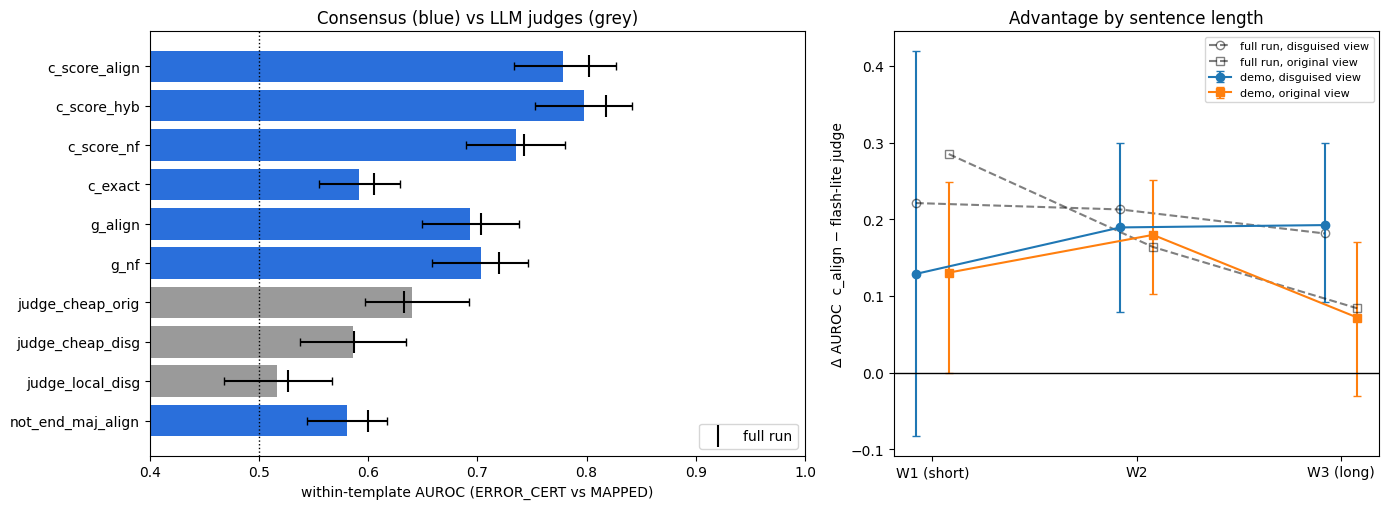

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.35, 1]})
order = ["c_score_align", "c_score_hyb", "c_score_nf", "c_exact", "g_align", "g_nf", "judge_cheap_orig", "judge_cheap_disg",
         "judge_local_disg", "not_end_maj_align"]
order = [m for m in order if A["metrics_untouched_all_scored"][m]["within_template"]["est"] is not None]
est = [A["metrics_untouched_all_scored"][m]["within_template"]["est"] for m in order]
ci = [A["metrics_untouched_all_scored"][m]["within_template"]["ci"] for m in order]
cols = ["#2a6fdb" if m.startswith(("c_", "g_", "not_")) else "#9a9a9a" for m in order]
y = np.arange(len(order))[::-1]
ax1.barh(y, est, color=cols, xerr=[[e - c[0] for e, c in zip(est, ci)], [c[1] - e for e, c in zip(est, ci)]], capsize=3)
full = [REF["metrics_untouched_all_scored_within_template"].get(m) for m in order]
ax1.scatter(full, y, marker="|", s=250, color="black", zorder=3, label="full run")
ax1.axvline(0.5, ls=":", color="k", lw=1)
ax1.set_yticks(y, order); ax1.set_xlim(0.4, 1.0); ax1.set_xlabel("within-template AUROC (ERROR_CERT vs MAPPED)")
ax1.set_title("Consensus (blue) vs LLM judges (grey)"); ax1.legend(loc="lower right")

for v, mk, lab in (("disg", "o", "disguised view"), ("orig", "s", "original view")):
    ws = ["W1", "W2", "W3"]
    nan2 = lambda x: np.nan if x is None else x
    dv = [nan2(A["complexity"][v]["word_tercile"][w]["delta"]) for w in ws]
    dci = [[nan2(c) for c in A["complexity"][v]["word_tercile"][w]["ci"]] for w in ws]
    x = np.arange(3) + (-0.08 if v == "disg" else 0.08)
    ax2.errorbar(x, dv, yerr=[[d - c[0] for d, c in zip(dv, dci)], [c[1] - d for d, c in zip(dv, dci)]], marker=mk, capsize=3, label=f"demo, {lab}")
    ax2.plot(x, [REF["complexity_word_tercile_delta"][v][w] for w in ws], ls="--", marker=mk, mfc="none", color="k", alpha=0.5,
             label=f"full run, {lab}")
ax2.axhline(0, color="k", lw=1)
ax2.set_xticks(range(3), ["W1 (short)", "W2", "W3 (long)"]); ax2.set_ylabel("Δ AUROC  c_align − flash-lite judge")
ax2.set_title("Advantage by sentence length"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## What this run shows
From the outputs above (seeded, so they are the same on every run):
* **Confirmatory verdict: NOT_TESTABLE.** 307 ERROR rows and 0 CORRECT rows in the subset, because the gloss gate failed (FALLBACK B).
* **Provisional headline reproduces.** c_align beats the flash-lite judge by +0.194 [0.134, 0.255] in the disguised view and +0.141 [0.091, 0.184] in the original view. The full run gives +0.217 and +0.171.
* **The advantage is carried by the aligner.** Aligner-free `c_exact` is level with the judge: Δ +0.001 in the disguised view and −0.048 in the original view, both with CIs covering 0. `c_exact − c_align` is −0.187.
* **Consensus adds to the judge, not the reverse.** Nested [judge + c] − [judge] is +0.215 / +0.176. [c + judge] − [c] is only +0.016 / +0.030.
* **The frontier judge is stronger.** gemini-3.1-pro beats c_align on the 62 frontier rows in this subset: −0.057 [−0.203, 0.043]; the full run gives −0.051 on 150 rows.
* **Operating point.** The label-free majority rule (c_align > 0.5) flags 96% of ERROR_CERT rows but also 71% of MAPPED rows. It ranks well but is a poor fixed-threshold detector.
* **Complexity.** In the original view the advantage falls from +0.130 (W1) to +0.072 (W3), the same direction as the full run (+0.285 → +0.084). On this subset, though, the delta-of-deltas CI covers 0, and the disguised view shows no decline.
* **Placebos behave.** Within-template label shuffles cover 0 in 19/20 runs (the full run had 17/20, one short of its 18/20 bar). The 100-shuffle supplement covers 0 in 92/100 (full run 95/100), and a random score gives AUROC ≈ 0.52.